In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

In [2]:
DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
FILE_PATH = DATA_DIR / "Helmholtz.h5"

In [3]:
import h5py

sample_idx = 0
sample_key = f"Sample_{sample_idx}"

with h5py.File(FILE_PATH, 'r') as f:
    a_sample = jnp.array(f[sample_key]['a'][:])
    bc_sample = f[sample_key]['bc'][()]
    u_sample = jnp.array(f[sample_key]['u'][:])

# Flatten for network
a_flat = a_sample.reshape(-1, 1)
u_flat = u_sample.reshape(-1, 1)

print(f"Extracted Spatial Field 'a' Shape: {a_flat.shape}")
print(f"Extracted Boundary Condition 'bc' Value: {bc_sample:.4f}")
print(f"Extracted Solution 'u' Shape: {u_flat.shape}")

E0712 20:25:33.631600  112425 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0712 20:25:33.697854  112320 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


Extracted Spatial Field 'a' Shape: (16384, 1)
Extracted Boundary Condition 'bc' Value: 0.4713
Extracted Solution 'u' Shape: (16384, 1)


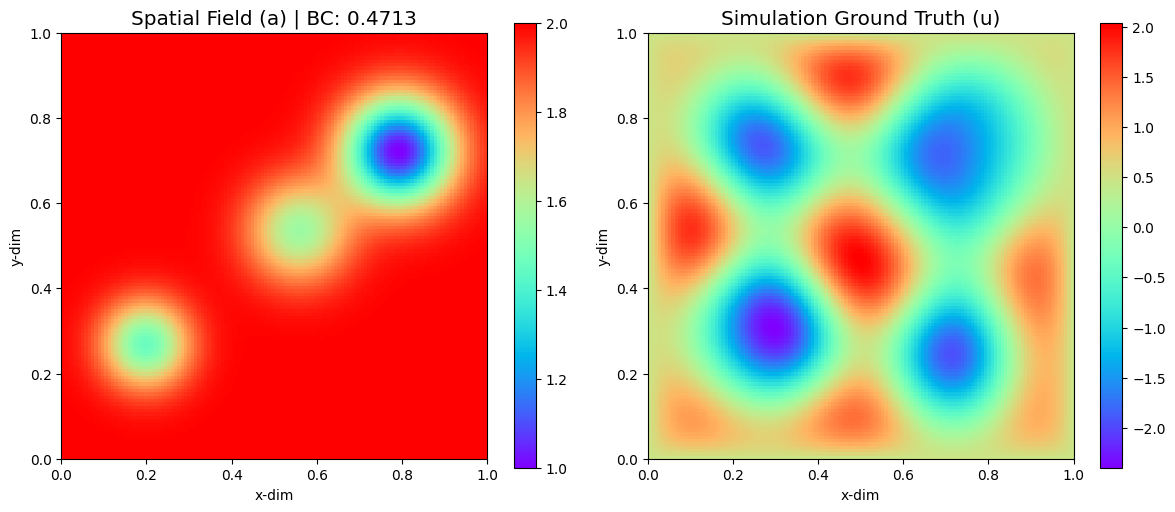

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotting 'a' (the spatial dependent function)
im1 = axes[0].imshow(a_sample.T, origin='lower', cmap='rainbow', extent=[0, 1, 0, 1])
fig.colorbar(im1, ax=axes[0])
axes[0].set_title(f'Spatial Field (a) | BC: {bc_sample:.4f}', fontsize='x-large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

# Plotting 'u' (the solution)
im2 = axes[1].imshow(u_sample.T, origin='lower', cmap='rainbow', extent=[0, 1, 0, 1])
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [5]:
nx, ny = 128, 128

x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
bc_val_array = jnp.ones_like(x_bc) * bc_sample

# Extract only interior points for PDE evaluation
interior_mask = ~bc_all
x_interior = x[interior_mask]
y_interior = y[interior_mask]
a_interior = a_flat[interior_mask]
u_interior = u_flat[interior_mask]

In [6]:
epochs = 1000
M = 512 
chunk_size = 256 
hidden_layers = [256, 256, 256, 256] 
# total_features = (2 * M) + sum(hidden_layers) # 1024 for concat
total_features = hidden_layers[-1]

sigma = 3.0 
tik_reg_fixed = 1e-4 
matrix_bc_weight = 1e11
pde_loss_weight = 1e-6
bc_loss_weight = 1e4
data_loss_weight = 0

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            
        return h 

model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [7]:
def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    return f_xx, f_yy

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    return f_xx_chunk, f_yy_chunk

def get_u_dir(params, x_val, y_val, w_current):
    f_xx, f_yy = get_f_dir(params, x_val, y_val)
    u_xx = jnp.dot(f_xx, w_current)
    u_yy = jnp.dot(f_yy, w_current)
    return u_xx, u_yy

# VMAPs reverted
f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [8]:
lr_schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=epochs, alpha=0.1)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)

omega_squared = 2 * (( 5.0 * jnp.pi / 2.0 )**2)

def get_A_and_b(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_chunks = []
    
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        
        f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        f_chunk = f_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        
        # PDE Matrix scaled by 1/sqrt(N_pde) for Mean Squared alignment
        A_pde_chunk = f_xx + f_yy + omega_squared * a_pde * f_chunk
        
        # BC Matrix scaled by BC weight AND 1/sqrt(N_bc)
        f_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx)
        A_bc_chunk = f_bc_chunk * jnp.sqrt(matrix_bc_weight)
        
        A_chunk = jnp.vstack([A_pde_chunk, A_bc_chunk])
        A_chunks.append(A_chunk)
        
    A_full = jnp.hstack(A_chunks)
    
    # Scale b vectors accordingly
    b_pde = jnp.zeros_like(a_pde) 
    b_bc = bc_val_arr * jnp.sqrt(matrix_bc_weight)
    b_full = jnp.vstack([b_pde, b_bc])
    
    return A_full, b_full

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def solve_w(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A, b = get_A_and_b(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    AtA = A.T @ A + tik_reg_fixed * jnp.eye(total_features)
    Atb = A.T @ b
    return jax.scipy.linalg.solve(AtA, Atb, assume_a='pos')

def compute_all_losses(params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch):
    w_current = solve_w(params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    
    u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, w_current)
    laplacian_u = u_xx + u_yy
    f_interior = f_spatial_vmap(params, x_batch, y_batch)
    u_pred_interior = jnp.dot(f_interior, w_current)
    
    pde_residual = laplacian_u + omega_squared * a_batch * u_pred_interior
    
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    
    loss_pde_unscaled = jnp.mean(pde_residual ** 2)
    loss_bc_unscaled = jnp.mean((u_bc_pred - bc_val_arr) ** 2)
    loss_data_unscaled = jnp.mean((u_pred_interior - u_batch) ** 2)
    
    loss_pde_scaled = loss_pde_unscaled * pde_loss_weight
    loss_bc_scaled = loss_bc_unscaled * bc_loss_weight
    loss_data_scaled = loss_data_unscaled * data_loss_weight
    
    aux_unscaled = (loss_pde_unscaled, loss_bc_unscaled, loss_data_unscaled)
    return (loss_pde_scaled, loss_bc_scaled, loss_data_scaled), aux_unscaled

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    # Vector-Jacobian Product to extract individual gradient norms
    loss_tuple, vjp_fn, aux_unscaled = jax.vjp(
        lambda p: compute_all_losses(p, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch),
        params,
        has_aux=True
    )
    
    l_pde_scaled, l_bc_scaled, l_data_scaled = loss_tuple
    
    # Pull gradients for each loss individually to monitor the "seesaw"
    pde_grads = vjp_fn((1.0, 0.0, 0.0))[0]
    bc_grads = vjp_fn((0.0, 1.0, 0.0))[0]
    data_grads = vjp_fn((0.0, 0.0, 1.0))[0]
    total_grads = vjp_fn((1.0, 1.0, 1.0))[0] # Sum of all gradients
    
    total_loss = l_pde_scaled + l_bc_scaled + l_data_scaled
    
    # Update network
    updates, opt_state = optimizer.update(total_grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    # Calculate global norms for logging
    grad_norms = (
        optax.global_norm(total_grads),
        optax.global_norm(pde_grads),
        optax.global_norm(bc_grads),
        optax.global_norm(data_grads)
    )
    
    return new_params, opt_state, total_loss, aux_unscaled, grad_norms

In [9]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_interior_points = x_interior.shape[0]
spatial_batch_size = 10000

history_total = []
history_pde = []
history_bc = []
history_data = []

for epoch in tqdm(range(epochs), desc="End-to-End PINN Training"):
    rng, shuffle_key = jax.random.split(rng)
    
    batch_idx = jax.random.choice(shuffle_key, total_interior_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk = x_interior[batch_idx]
    y_chunk = y_interior[batch_idx]
    a_chunk = a_interior[batch_idx]
    u_chunk = u_interior[batch_idx]
    
    params, opt_state, loss, (l_pde, l_bc, l_data), norms = update_network(
        params, opt_state, x_chunk, y_chunk, a_chunk, x_bc, y_bc, bc_val_array, u_chunk, total_features, chunk_size
    )
    
    history_total.append(float(loss))
    history_pde.append(float(l_pde))
    history_bc.append(float(l_bc))
    history_data.append(float(l_data))
    
    if epoch % 10 == 0:
        g_tot, g_pde, g_bc, g_data = norms
        print(f"Epoch {epoch:<3} | Tot Loss (scaled): {loss:.3e} | PDE(un): {l_pde:.3e} | BC(un): {l_bc:.3e} | Data(un): {l_data:.3e}")
        print(f"            └─ Grad Norms => Tot: {g_tot:.3e} | PDE: {g_pde:.3e} | BC: {g_bc:.3e} | Data: {g_data:.3e}")

End-to-End PINN Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0   | Tot Loss (scaled): 2.048e+00 | PDE(un): 1.002e+06 | BC(un): 1.046e-04 | Data(un): 7.067e-01
            └─ Grad Norms => Tot: 4.791e+01 | PDE: 1.514e+01 | BC: 3.901e+01 | Data: 0.000e+00
Epoch 10  | Tot Loss (scaled): 5.679e-02 | PDE(un): 4.959e+04 | BC(un): 7.193e-07 | Data(un): 6.824e-01
            └─ Grad Norms => Tot: 4.843e-01 | PDE: 2.908e-01 | BC: 3.508e-01 | Data: 0.000e+00
Epoch 20  | Tot Loss (scaled): 2.971e-02 | PDE(un): 2.717e+04 | BC(un): 2.539e-07 | Data(un): 6.838e-01
            └─ Grad Norms => Tot: 1.902e-01 | PDE: 1.247e-01 | BC: 1.233e-01 | Data: 0.000e+00
Epoch 30  | Tot Loss (scaled): 1.937e-02 | PDE(un): 1.846e+04 | BC(un): 9.122e-08 | Data(un): 6.772e-01
            └─ Grad Norms => Tot: 1.006e-01 | PDE: 7.962e-02 | BC: 5.155e-02 | Data: 0.000e+00
Epoch 40  | Tot Loss (scaled): 1.446e-02 | PDE(un): 1.399e+04 | BC(un): 4.682e-08 | Data(un): 6.704e-01
            └─ Grad Norms => Tot: 6.890e-02 | PDE: 5.884e-02 | BC: 2.855e-02 | Data: 0.000e+00
Epoch

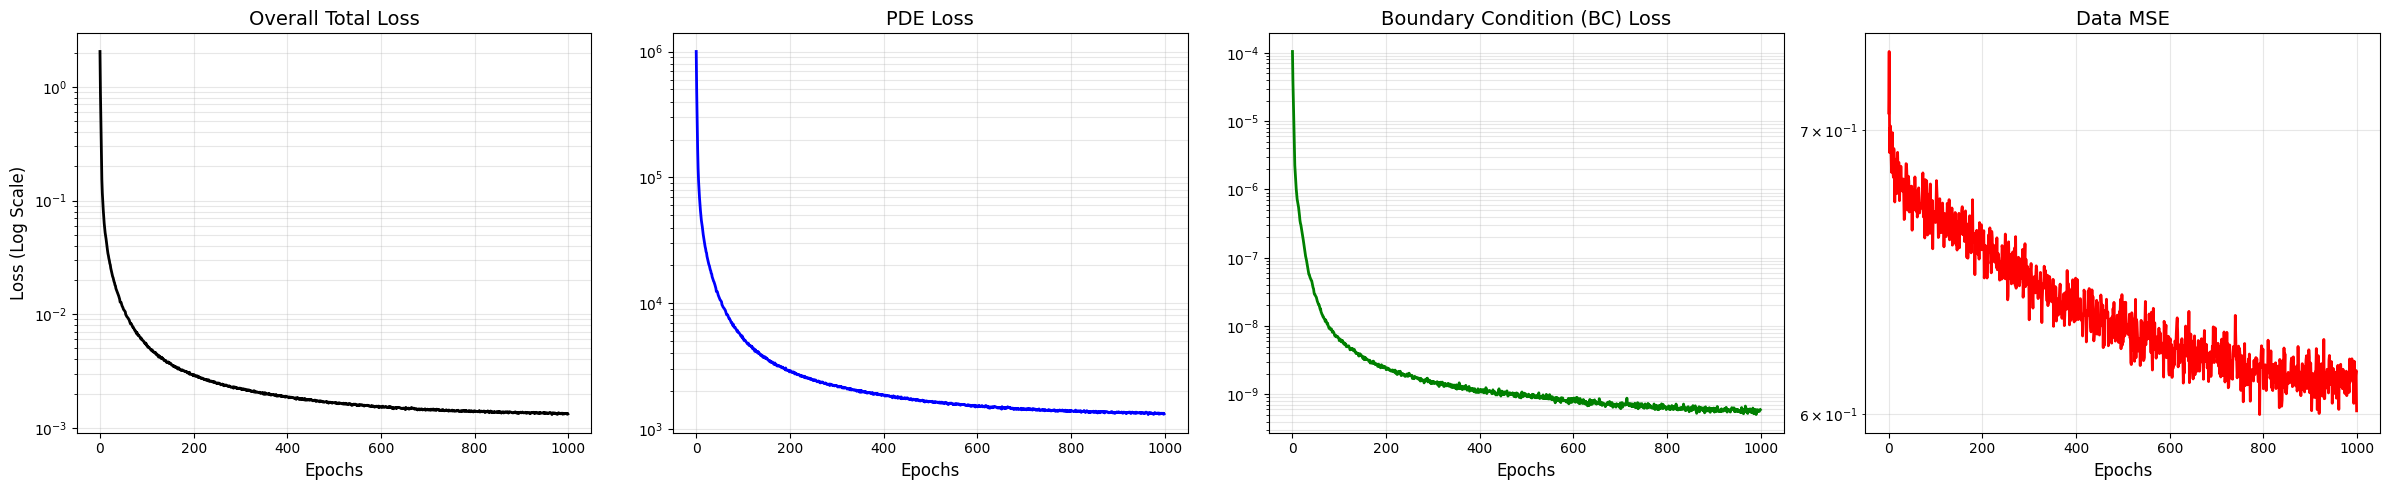

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Plot 1: Overall Total Loss
axes[0].plot(history_total, color='black', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_title('Overall Total Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss (Log Scale)', fontsize=12)
axes[0].grid(True, which="both", ls="-", alpha=0.3)

# Plot 2: PDE Loss
axes[1].plot(history_pde, color='blue', linewidth=2)
axes[1].set_yscale('log')
axes[1].set_title('PDE Loss', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].grid(True, which="both", ls="-", alpha=0.3)

# Plot 3: BC Loss
axes[2].plot(history_bc, color='green', linewidth=2)
axes[2].set_yscale('log')
axes[2].set_title('Boundary Condition (BC) Loss', fontsize=14)
axes[2].set_xlabel('Epochs', fontsize=12)
axes[2].grid(True, which="both", ls="-", alpha=0.3)

# Plot 4: Data MSE
axes[3].plot(history_data, color='red', linewidth=2)
axes[3].set_yscale('log')
axes[3].set_title('Data MSE', fontsize=14)
axes[3].set_xlabel('Epochs', fontsize=12)
axes[3].grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

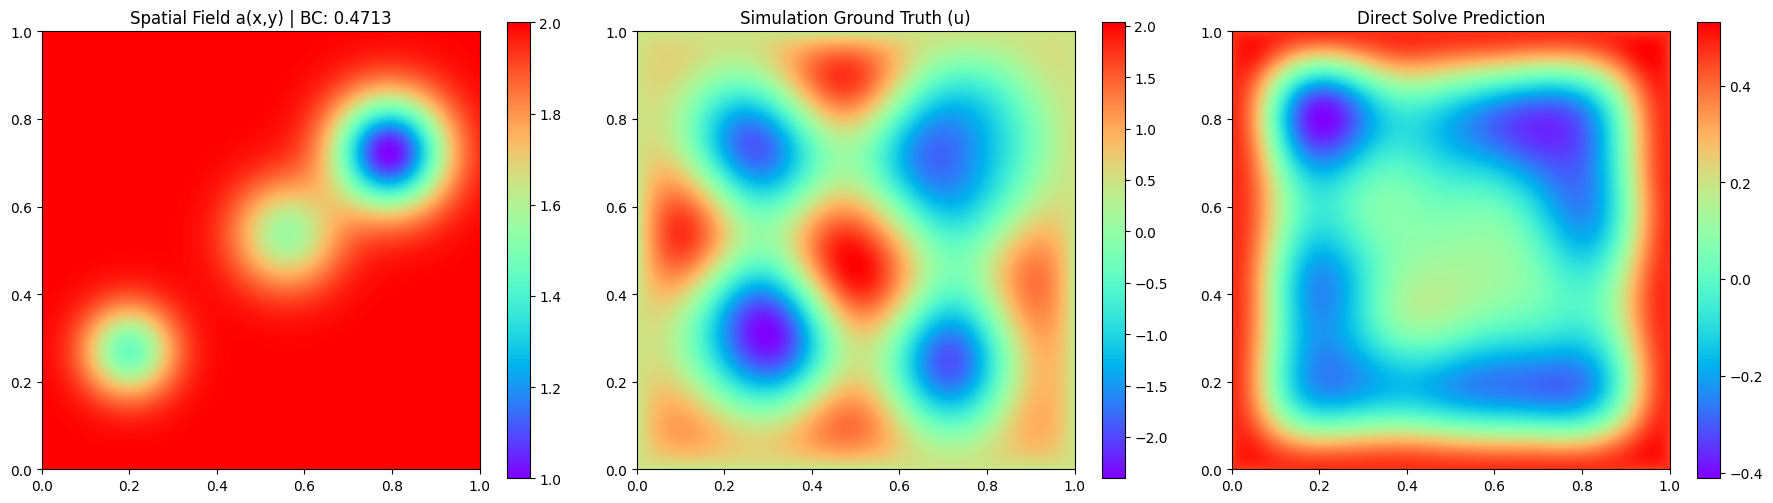

In [11]:
w_final = solve_w(params, x, y, a_flat, x_bc, y_bc, bc_val_array, total_features, chunk_size)
f_full = f_spatial_vmap(params, x, y)
u_pred_full = jnp.dot(f_full, w_final)

# Plotting
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Direct Solve Prediction')

plt.tight_layout()
plt.show()